# 🤖 Machine Learning — Notebook de Projeto

**Disciplina:** Machine Learning  
**Professor:** Messias Batista  
**Aluno(a):**  
**Data:**  
**Dataset:** dadosHab.csv — Avaliação Imobiliária  
**Problema de negócio:** Prever o valor de imóveis residenciais com base em características como área, distância à praia e distância à farmácia, utilizando Regressão Linear Simples e Múltipla.  

---
## 1. 📦 Importações

Importe aqui todas as bibliotecas que serão utilizadas ao longo do projeto.

Você precisará de bibliotecas para:
- **Manipulação de dados** — leitura, transformação e análise de tabelas
- **Visualização** — criação de gráficos e figuras
- **Pré-processamento** — divisão dos dados, normalização e codificação de variáveis
- **Algoritmos de Machine Learning** — os modelos que serão treinados
- **Métricas de avaliação** — para medir o desempenho dos modelos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from math import sqrt

---
## 2. 📂 Carregamento dos Dados

Carregue o dataset e faça uma primeira inspeção para entender com o que você está trabalhando.

Nesta etapa você deve responder:
- Quantas linhas e colunas o dataset possui?
- Quais são os tipos de cada coluna?
- Existem valores nulos? Em quais colunas e em qual quantidade?

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/mrafaelbatista/uniesp-mba-dados-machine-learning/master/db/dadosHab.csv')
df.head()

,Valor,Area,Dist_Praia,Dist_Farmacia
0,4600000,280,0.240925,0.793637
1,900000,208,0.904136,0.134494
2,2550000,170,0.059525,0.423318
3,550000,100,2.883181,0.525064
4,2200000,164,0.239758,0.192374


In [3]:
print(f"Dimensões: {df.shape}")
print(f"\nTipos de dados:\n{df.dtypes}")
print(f"\nValores nulos:\n{df.isnull().sum()}")

Dimensões: (5000, 4)

Tipos de dados:
Valor              int64
Area               int64
Dist_Praia       float64
Dist_Farmacia    float64
dtype: object

Valores nulos:
Valor            0
Area             0
Dist_Praia       0
Dist_Farmacia    0
dtype: int64


---
## 3. 🔍 Análise Exploratória de Dados (EDA)

Explore os dados antes de construir qualquer modelo. Esta é uma das etapas mais importantes do processo.

Nesta etapa você deve:
- Calcular estatísticas descritivas das variáveis numéricas
- Analisar a distribuição da variável alvo (está balanceada?)
- Visualizar a distribuição das demais variáveis
- Identificar possíveis outliers
- Analisar a correlação entre as variáveis

In [4]:
# Estatísticas descritivas
df.describe()

,Valor,Area,Dist_Praia,Dist_Farmacia
count,5.000000e+03,5000.000000,5000.000000,5000.000000
mean,1.402926e+06,121.944800,3.021920,0.497160
std,1.883269e+06,90.536969,3.170933,0.291355
min,7.500000e+04,16.000000,0.000000,0.000331
25%,4.600000e+05,70.000000,0.438417,0.238640
50%,8.200000e+05,93.000000,1.476958,0.503260
75%,1.590000e+06,146.000000,5.605379,0.747737
max,2.500000e+07,2000.000000,17.962942,0.999987


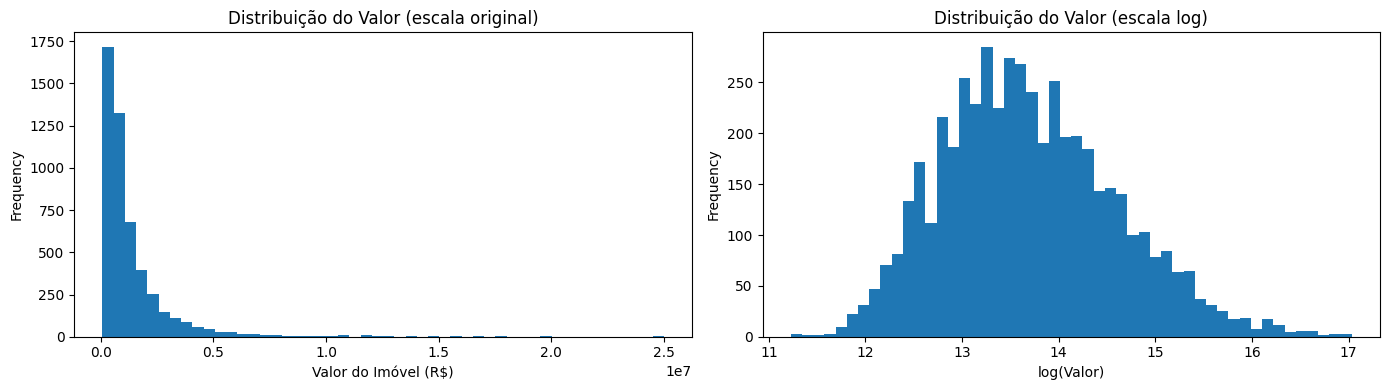

In [5]:
# Distribuição da variável alvo
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['Valor'].plot(kind='hist', bins=50, ax=axes[0], title='Distribuição do Valor (escala original)')
axes[0].set_xlabel('Valor do Imóvel (R$)')

np.log(df['Valor']).plot(kind='hist', bins=50, ax=axes[1], title='Distribuição do Valor (escala log)')
axes[1].set_xlabel('log(Valor)')

plt.tight_layout()
plt.show()

Correlação entre variáveis:
                  Valor      Area  Dist_Praia  Dist_Farmacia
Valor          1.000000  0.710974   -0.366542      -0.024366
Area           0.710974  1.000000   -0.283371      -0.030990
Dist_Praia    -0.366542 -0.283371    1.000000       0.025645
Dist_Farmacia -0.024366 -0.030990    0.025645       1.000000


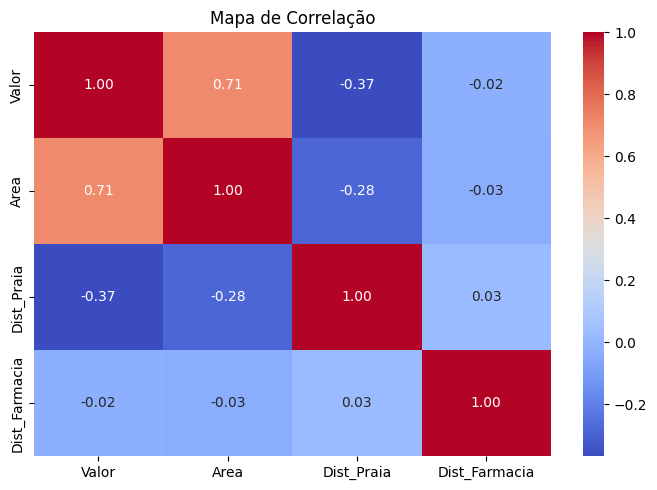

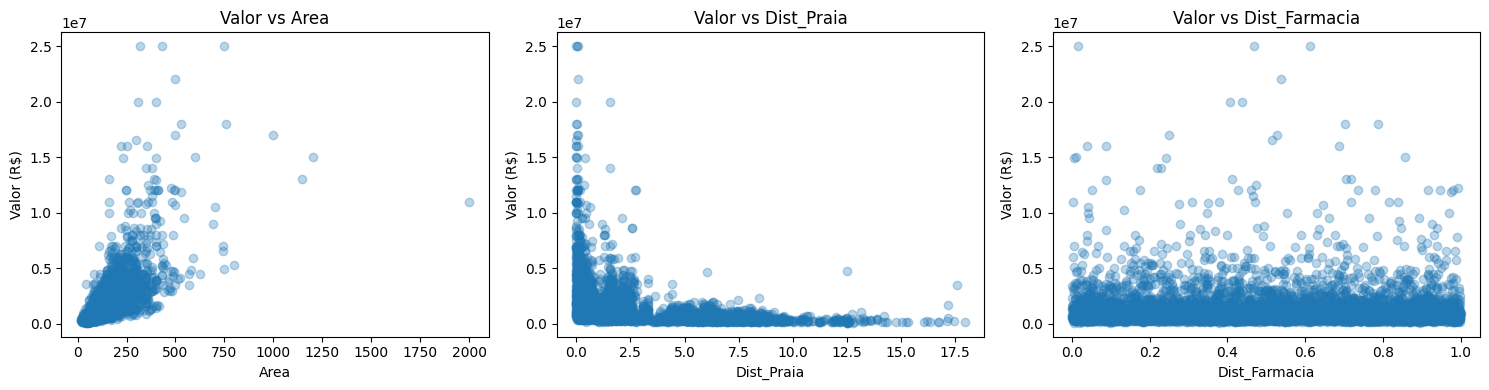

In [6]:
# Correlações
print("Correlação entre variáveis:")
print(df.corr())

# Heatmap de correlação
plt.figure(figsize=(7, 5))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Mapa de Correlação')
plt.tight_layout()
plt.show()

# Scatter: Valor vs cada feature
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(['Area', 'Dist_Praia', 'Dist_Farmacia']):
    axes[i].scatter(df[col], df['Valor'], alpha=0.3)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Valor (R$)')
    axes[i].set_title(f'Valor vs {col}')
plt.tight_layout()
plt.show()

---
## 4. 🛠️ Pré-processamento

Prepare os dados para que o modelo consiga aprender corretamente.

Nesta etapa você deve:
- Remover colunas que não contribuem para o modelo
- Tratar os valores nulos (remover ou preencher)
- Converter variáveis categóricas em numéricas
- Separar as features (X) da variável alvo (y)
- Aplicar normalização ou padronização se necessário

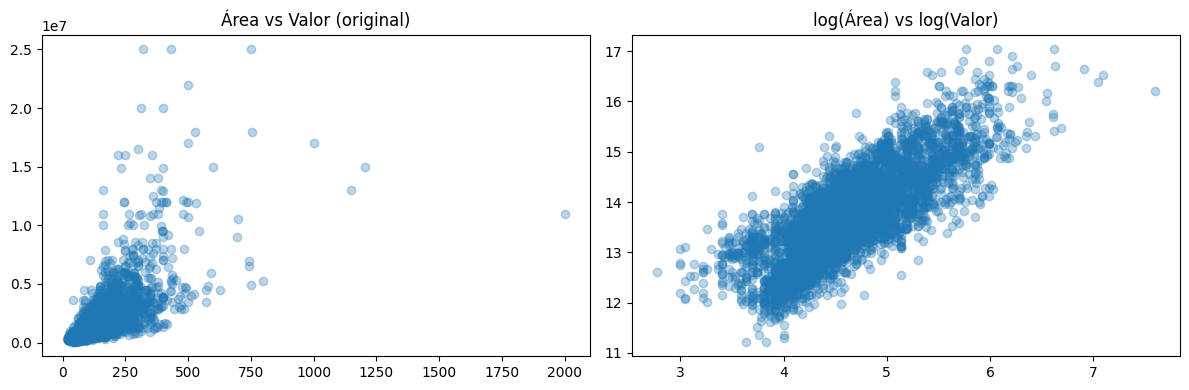

In [7]:
# Aplicar transformação logarítmica para linearizar a relação (Regressão Simples)
dados = df.copy()
dados['log_Valor'] = np.log(dados['Valor'])
dados['log_Area']  = np.log(dados['Area'])

# Comparação visual antes/depois do log
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(dados['Area'], dados['Valor'], alpha=0.3)
axes[0].set_title('Área vs Valor (original)')
axes[1].scatter(dados['log_Area'], dados['log_Valor'], alpha=0.3)
axes[1].set_title('log(Área) vs log(Valor)')
plt.tight_layout()
plt.show()

In [8]:
# Regressão Linear Simples — 1 feature (escala log)
X_simples = dados[['log_Area']]
y_simples  = dados['log_Valor']

# Regressão Linear Múltipla — 3 features (escala original)
X_multipla = df[['Area', 'Dist_Praia', 'Dist_Farmacia']]
y_multipla = df['Valor']

print(f"X simples:   {X_simples.shape}   |   y simples:   {y_simples.shape}")
print(f"X múltipla:  {X_multipla.shape}   |   y múltipla:  {y_multipla.shape}")

X simples:   (5000, 1)   |   y simples:   (5000,)
X múltipla:  (5000, 3)   |   y múltipla:  (5000,)


---
## 5. ✂️ Separação Treino / Teste

Divida os dados em dois conjuntos: um para treinar o modelo e outro para testá-lo.

Lembre-se:
- O modelo deve ser treinado **apenas** com os dados de treino
- Os dados de teste simulam situações novas, que o modelo nunca viu
- Uma divisão comum é 70% treino e 30% teste
- Use o parâmetro `stratify` para manter a proporção das classes

In [9]:
# Divisão treino/teste — Regressão Simples
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simples, y_simples, test_size=0.30, random_state=42)

# Divisão treino/teste — Regressão Múltipla
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multipla, y_multipla, test_size=0.30, random_state=42)

print(f"Simples  — Treino: {X_train_s.shape}, Teste: {X_test_s.shape}")
print(f"Múltipla — Treino: {X_train_m.shape}, Teste: {X_test_m.shape}")

Simples  — Treino: (3500, 1), Teste: (1500, 1)
Múltipla — Treino: (3500, 3), Teste: (1500, 3)


---
## 6. 🧠 Treinamento do Modelo

Escolha um algoritmo, instancie o modelo e treine-o com os dados de treino.

Lembre-se:
- O treinamento acontece com o método `fit()`
- As previsões são feitas com o método `predict()`
- Você pode testar mais de um algoritmo e compará-los na seção 8

In [10]:
# Regressão Linear Simples (escala log)
lr_simples = LinearRegression()
lr_simples.fit(X_train_s, y_train_s)
print(f"Simples — Intercepto: {lr_simples.intercept_:.4f}")
print(f"          Coeficiente: {lr_simples.coef_}")

print()

# Regressão Linear Múltipla (escala original)
lr_multipla = LinearRegression()
lr_multipla.fit(X_train_m, y_train_m)
print(f"Múltipla — Intercepto: {lr_multipla.intercept_:.2f}")
print(f"           Coeficientes: {lr_multipla.coef_}")

Simples — Intercepto: 7.8115
          Coeficiente: [1.27030798]

Múltipla — Intercepto: 70111.48
           Coeficientes: [  13290.50727564 -108292.21055439   67608.60319725]


In [11]:
# Previsões nos dados de teste
y_pred_s = lr_simples.predict(X_test_s)
y_pred_m = lr_multipla.predict(X_test_m)

# Exemplo prático: imóvel de 200 m², a 0.25 km da praia e 0.80 km da farmácia
imovel_exemplo = [[200, 0.25, 0.80]]
valor_previsto = lr_multipla.predict(imovel_exemplo)[0]
print(f"Valor previsto para o imóvel de exemplo (Múltipla): R$ {valor_previsto:,.2f}")

# Verificação com Regressão Simples (necessita de log)
area_log = np.log(200)
valor_log = lr_simples.predict([[area_log]])[0]
print(f"Valor previsto para 200 m² (Simples, back-transform): R$ {np.exp(valor_log):,.2f}")

Valor previsto para o imóvel de exemplo (Múltipla): R$ 2,755,226.77
Valor previsto para 200 m² (Simples, back-transform): R$ 2,067,717.71


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


---
## 7. 📊 Avaliação do Modelo

Meça o desempenho do modelo utilizando métricas adequadas ao problema.

Para problemas de **regressão**, avalie:
- **R²** — proporção da variância explicada pelo modelo (quanto mais próximo de 1, melhor)
- **RMSE** — raiz do erro quadrático médio, na mesma unidade da variável alvo
- **MAE** — erro absoluto médio, fácil de interpretar
- **Resíduos** — distribuição dos erros; deve ser centrada em zero e simétrica

In [12]:
# R² Score
r2_s = r2_score(y_test_s, y_pred_s)
r2_m = r2_score(y_test_m, y_pred_m)

print(f"R² — Regressão Simples  (log): {r2_s:.4f}")
print(f"R² — Regressão Múltipla:       {r2_m:.4f}")

R² — Regressão Simples  (log): 0.6394
R² — Regressão Múltipla:       0.5691


In [13]:
# RMSE e MAE
rmse_s = sqrt(mean_squared_error(y_test_s, y_pred_s))
mae_s  = mean_absolute_error(y_test_s, y_pred_s)

rmse_m = sqrt(mean_squared_error(y_test_m, y_pred_m))
mae_m  = mean_absolute_error(y_test_m, y_pred_m)

print(f"{'Métrica':<8} {'Simples (log)':>16} {'Múltipla (R$)':>20}")
print(f"{'RMSE':<8} {rmse_s:>16.4f} {rmse_m:>20,.2f}")
print(f"{'MAE':<8} {mae_s:>16.4f} {mae_m:>20,.2f}")

Métrica     Simples (log)        Múltipla (R$)
RMSE               0.5416         1,189,827.25
MAE                0.4391           590,619.70


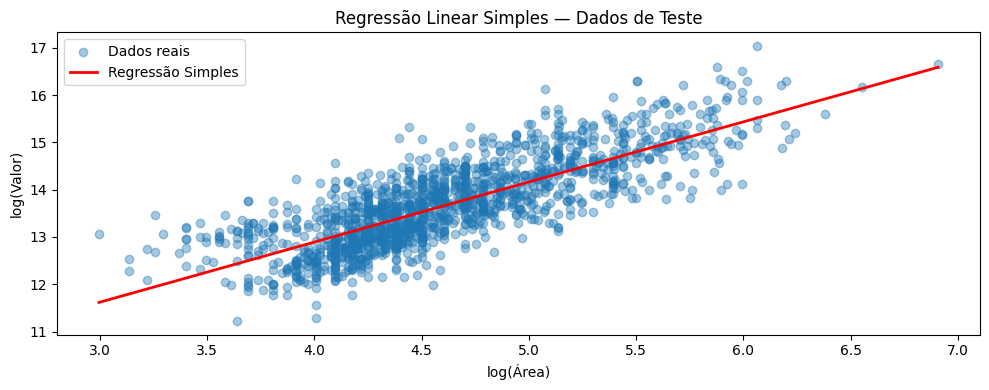

In [14]:
# Curva ajustada — Regressão Simples (escala log)
area_range = pd.DataFrame(
    {'log_Area': np.linspace(X_test_s['log_Area'].min(), X_test_s['log_Area'].max(), 200)}
)
y_line = lr_simples.predict(area_range)

plt.figure(figsize=(10, 4))
plt.scatter(X_test_s['log_Area'], y_test_s, alpha=0.4, label='Dados reais')
plt.plot(area_range['log_Area'], y_line, color='red', lw=2, label='Regressão Simples')
plt.xlabel('log(Área)')
plt.ylabel('log(Valor)')
plt.title('Regressão Linear Simples — Dados de Teste')
plt.legend()
plt.tight_layout()
plt.show()

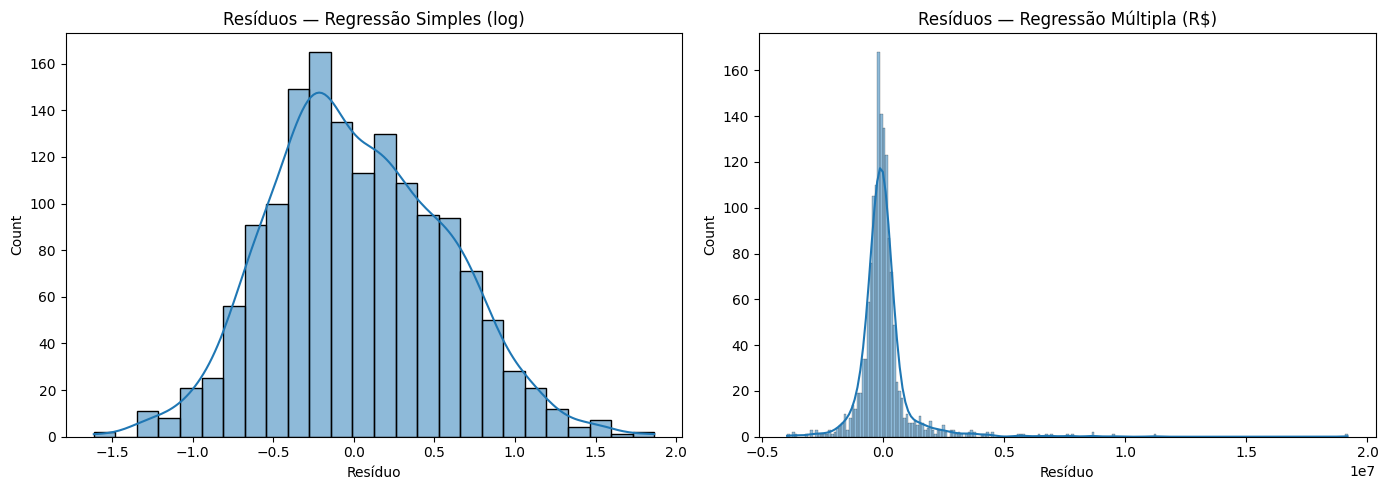

In [15]:
# Distribuição dos resíduos
residuo_s = y_test_s.values - y_pred_s
residuo_m = y_test_m.values - y_pred_m

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(residuo_s, kde=True, ax=axes[0])
axes[0].set_title('Resíduos — Regressão Simples (log)')
axes[0].set_xlabel('Resíduo')

sns.histplot(residuo_m, kde=True, ax=axes[1])
axes[1].set_title('Resíduos — Regressão Múltipla (R$)')
axes[1].set_xlabel('Resíduo')

plt.tight_layout()
plt.show()

---
## 8. 🏆 Comparação de Modelos

Teste outros algoritmos e compare os resultados para identificar o mais adequado ao seu problema.

Dica: use validação cruzada para comparar os modelos de forma justa,
pois ela elimina o efeito da aleatoriedade de uma única divisão treino/teste.

                               R²          RMSE            MAE
Modelo                                                        
Regressão Simples (log)  0.639402  5.415633e-01       0.439147
Regressão Múltipla       0.569117  1.189827e+06  590619.697353


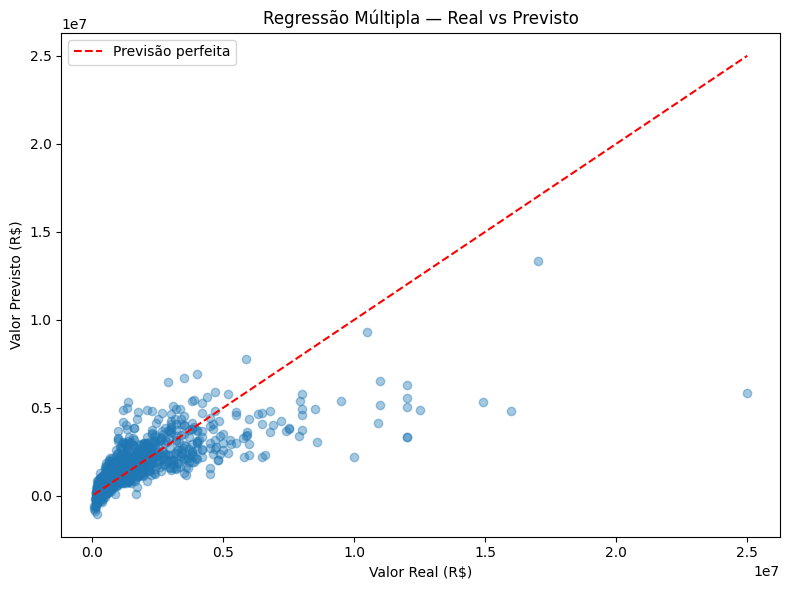


Ridge Regression — R²: 0.5691 | RMSE: 1,189,823.74 | MAE: 590,613.21


In [16]:
# Tabela comparativa de métricas
comparacao = pd.DataFrame({
    'Modelo': ['Regressão Simples (log)', 'Regressão Múltipla'],
    'R²':     [r2_s,   r2_m],
    'RMSE':   [rmse_s, rmse_m],
    'MAE':    [mae_s,  mae_m],
}).set_index('Modelo')
print(comparacao.to_string())

# Real vs Previsto — Regressão Múltipla
plt.figure(figsize=(8, 6))
plt.scatter(y_test_m, y_pred_m, alpha=0.4)
lim = [y_test_m.min(), y_test_m.max()]
plt.plot(lim, lim, 'r--', label='Previsão perfeita')
plt.xlabel('Valor Real (R$)')
plt.ylabel('Valor Previsto (R$)')
plt.title('Regressão Múltipla — Real vs Previsto')
plt.legend()
plt.tight_layout()
plt.show()

# Ridge Regression como alternativa com regularização
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_m, y_train_m)
y_pred_ridge = ridge.predict(X_test_m)

r2_ridge   = r2_score(y_test_m, y_pred_ridge)
rmse_ridge = sqrt(mean_squared_error(y_test_m, y_pred_ridge))
mae_ridge  = mean_absolute_error(y_test_m, y_pred_ridge)

print(f"\nRidge Regression — R²: {r2_ridge:.4f} | RMSE: {rmse_ridge:,.2f} | MAE: {mae_ridge:,.2f}")

---
## 9. 📝 Conclusões

Responda as perguntas abaixo com base nos resultados obtidos:

**1. Qual algoritmo apresentou melhor desempenho? Por quê?**  
> _Escreva aqui_

**2. O modelo está sofrendo overfitting ou underfitting? Como você identificou?**  
> _Escreva aqui_

**3. Os resultados respondem à pergunta de negócio levantada no início?**  
> _Escreva aqui_

**4. Qual seria o próximo passo para melhorar o modelo?**  
> _Escreva aqui_

---
### 🔖 Referências
- Dataset: dadosHab.csv — gerado para fins didáticos
- Scikit-learn: https://scikit-learn.org
- Material da disciplina: www.mrafaelbatista.dev
